In [8]:
import pandas as pd
print("working")


working


In [9]:
df = pd.read_csv("../data/sample_emails.csv")
df.head()


,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [10]:
# Handle missing values
df['subject'] = df['subject'].fillna('').str.strip()
df['body'] = df['body'].fillna('').str.strip()

# Create cleaned lowercase versions
df['subject_clean'] = df['subject'].str.lower()
df['body_clean'] = df['body'].str.lower()

df.head()


,id,sender,subject,body,priority,label,subject_clean,body_clean
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a..."
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,big billion sale is live,flat 70% off on electronics. limited period of...
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,unusual login attempt,we detected a login attempt to your account fr...
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter,weekly tech newsletter,"in this week's edition, learn about ai agents,..."
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal,coffee this weekend?,"hey, long time no see! are you free this weeke..."


In [11]:
df.columns


Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'subject_clean',
       'body_clean'],
      dtype='object')

In [12]:
df['combined_text'] = df['subject'] + " " + df['body']
df[['subject', 'body', 'combined_text']].head()


,subject,body,combined_text
0,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
1,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,Big Billion Sale is Live Flat 70% OFF on elect...
2,Unusual Login Attempt,We detected a login attempt to your account fr...,Unusual Login Attempt We detected a login atte...
3,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...","Weekly Tech Newsletter In this week's edition,..."
4,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...","Coffee this weekend? Hey, long time no see! Ar..."


In [13]:
df[df['combined_text'].str.contains("offer", case=False)]


,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,big billion sale is live,flat 70% off on electronics. limited period of...,Big Billion Sale is Live Flat 70% OFF on elect...


In [14]:
df[df['priority'] == "high"]


,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,unusual login attempt,we detected a login attempt to your account fr...,Unusual Login Attempt We detected a login atte...
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not s...,high,spam,"you won $1,000,000!!!",click here to claim your lottery now. do not s...,"You won $1,000,000!!! Click here to claim your..."
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work,project update required,please share the status update of your project...,Project Update Required Please share the statu...


In [15]:
df[df['label'] == "work"]


,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work,project update required,please share the status update of your project...,Project Update Required Please share the statu...
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory security awareness training is ...,medium,work,reminder: complete mandatory training,your mandatory security awareness training is ...,Reminder: Complete Mandatory Training Your man...


In [16]:
df[df['sender'].str.contains("hr", case=False)]


,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."


In [17]:
# Clean text
df['subject'] = df['subject'].fillna('').str.strip().str.lower()
df['body'] = df['body'].fillna('').str.strip().str.lower()

# Combine subject + body
df['combined_text'] = df['subject'] + " " + df['body']


In [18]:
def extract_priority(text):
    text = text.lower()

    if "high priority" in text or "urgent" in text or "immediately" in text:
        return "high"
    elif "medium priority" in text or "normal" in text:
        return "medium"
    elif "low priority" in text or "not urgent" in text:
        return "low"
    else:
        return "unknown"


In [19]:
# Clean priority column
df['priority'] = df['priority'].str.strip().str.lower()

df[['subject', 'priority']].head()


,subject,priority
0,offer letter - please sign,high
1,big billion sale is live,low
2,unusual login attempt,high
3,weekly tech newsletter,low
4,coffee this weekend?,medium


In [20]:
df.describe(include="all")

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
count,8.00000,8,8,8,8,8,8,8,8
unique,NaN,8,8,8,3,7,8,8,8
top,NaN,hr@company.com,offer letter - please sign,"dear candidate, congratulations! please sign a...",high,work,offer letter - please sign,"dear candidate, congratulations! please sign a...","offer letter - please sign dear candidate, con..."
freq,NaN,1,1,1,4,2,1,1,1
mean,4.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [22]:
df.shape
df.columns


Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'subject_clean',
       'body_clean', 'combined_text'],
      dtype='object')

In [23]:
df.isnull().sum()

id               0
sender           0
subject          0
body             0
priority         0
label            0
subject_clean    0
body_clean       0
combined_text    0
dtype: int64

In [24]:
df['clean_txt']=df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_txt']].head()

,body,clean_txt
0,"dear candidate, congratulations! please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,flat 70% off on electronics. limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,we detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"in this week's edition, learn about ai agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"hey, long time no see! are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [25]:
df['priority'].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [26]:
print(df.shape)  



(8, 10)


In [27]:
from collections import Counter

all_words = ' '.join(df['clean_txt']).split()
word_freq = Counter(all_words)
word_freq.most_common(10)


[('dearcandidatecongratulationspleasesignanduploadyourofferletterbytodayevening',
  1),
 ('flatoffonelectronicslimitedperiodoffervisitourstorenow', 1),
 ('wedetectedaloginattempttoyouraccountfromanewdeviceifthiswasnotyoupleaseresetyourpassword',
  1),
 ('inthisweekseditionlearnaboutaiagentslanggraphandmore', 1),
 ('heylongtimenoseeareyoufreethisweekendforcoffee', 1),
 ('clickheretoclaimyourlotterynowdonotsharethiswithanyone', 1),
 ('pleasesharethestatusupdateofyourprojectbeforepmtoday', 1),
 ('yourmandatorysecurityawarenesstrainingisduetomorrow', 1)]

In [28]:
df.columns


Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'subject_clean',
       'body_clean', 'combined_text', 'clean_txt'],
      dtype='object')

In [29]:
df['clean_txt']=df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)

In [30]:
all_words = ' '.join(df['clean_txt']).split()

In [31]:
len(all_words)

8

In [32]:
import nltk #natural language toolkit
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word not in stop_words]
filtered_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\psinc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['dearcandidatecongratulationspleasesignanduploadyourofferletterbytodayevening',
 'flatoffonelectronicslimitedperiodoffervisitourstorenow',
 'wedetectedaloginattempttoyouraccountfromanewdeviceifthiswasnotyoupleaseresetyourpassword',
 'inthisweekseditionlearnaboutaiagentslanggraphandmore',
 'heylongtimenoseeareyoufreethisweekendforcoffee',
 'clickheretoclaimyourlotterynowdonotsharethiswithanyone',
 'pleasesharethestatusupdateofyourprojectbeforepmtoday',
 'yourmandatorysecurityawarenesstrainingisduetomorrow']

In [33]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [34]:
pip install nltk pandas


Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter


In [36]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\psinc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
df = pd.read_csv(r'..\data\sample_emails.csv')
df.head()


,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [38]:
df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
df['clean_text'] = df['text'].str.lower().str.strip()


In [39]:
stop_words = set(stopwords.words('english'))

df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)


In [40]:
df[['text', 'clean_text']].head(3)


,text,clean_text
0,"Offer Letter - Please Sign Dear Candidate, Con...","offer letter - please sign dear candidate, con..."
1,Big Billion Sale is Live Flat 70% OFF on elect...,big billion sale live flat 70% electronics. li...
2,Unusual Login Attempt We detected a login atte...,unusual login attempt detected login attempt a...


In [41]:
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

word_freq.most_common(10)


[('please', 4),
 ('offer', 2),
 ('letter', 2),
 ('sign', 2),
 ('now.', 2),
 ('login', 2),
 ('attempt', 2),
 ('share', 2),
 ('project', 2),
 ('update', 2)]

In [42]:
import nltk
from nltk.stem import PorterStemmer


In [43]:
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\psinc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
print(df.head())


   id                sender                     subject  \
0   1        hr@company.com  Offer Letter - Please Sign   
1   2  noreply@shopping.com    Big Billion Sale is Live   
2   3     alerts@mybank.com       Unusual Login Attempt   
3   4   newsletter@blog.com      Weekly Tech Newsletter   
4   5   friend123@gmail.com        Coffee this weekend?   

                                                body priority       label  \
0  Dear Candidate, Congratulations! Please sign a...     high   important   
1  Flat 70% OFF on electronics. Limited period of...      low   promotion   
2  We detected a login attempt to your account fr...     high    security   
3  In this week's edition, learn about AI agents,...      low  newsletter   
4  Hey, long time no see! Are you free this weeke...   medium    personal   

                                                text  \
0  Offer Letter - Please Sign Dear Candidate, Con...   
1  Big Billion Sale is Live Flat 70% OFF on elect...   
2  Unusual Log

In [59]:


df['stemmed_body'] = df['body'].astype(str).apply(
    lambda text: ' '.join(stemmer.stem(word) for word in text.split())
)

df[['body', 'stemmed_body']].head()


,body,stemmed_body
0,"Dear Candidate, Congratulations! Please sign a...","dear candidate, congratulations! pleas sign an..."
1,Flat 70% OFF on electronics. Limited period of...,flat 70% off on electronics. limit period offe...
2,We detected a login attempt to your account fr...,we detect a login attempt to your account from...
3,"In this week's edition, learn about AI agents,...","in thi week' edition, learn about ai agents, l..."
4,"Hey, long time no see! Are you free this weeke...","hey, long time no see! are you free thi weeken..."


In [46]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


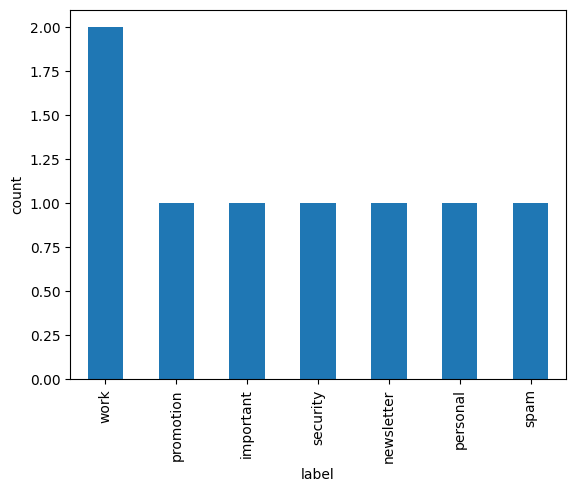

In [57]:
import matplotlib.pyplot as plt

category_counts = df['label'].value_counts()

category_counts.plot(kind='bar')
plt.ylabel('count')
plt.show()


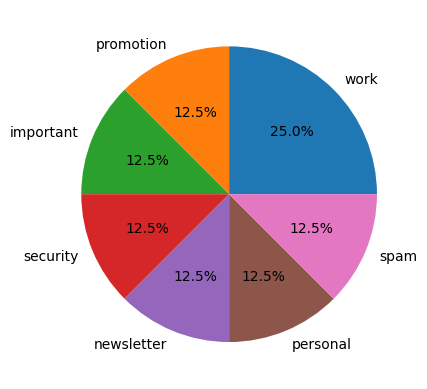

In [55]:
import matplotlib.pyplot as plt

category_counts = df['label'].value_counts()

category_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()


In [49]:
from collections import Counter


In [ ]:
from collections import Counter

top_keywords = {}

for cat, texts in grouped.items():
    texts = [str(t) for t in texts] 
    words = ' '.join(texts).split()
    top_keywords[cat] = Counter(words).most_common(5)

top_keywords


{'important': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'newsletter': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'personal': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'promotion': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'security': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'spam': [('your', 3), ('of', 2), ('Please', 2), ('to', 2), ('this', 2)],
 'work': [('your', 6), ('of', 4), ('Please', 4), ('to', 4), ('this', 4)]}

In [66]:
rules = {
    "Promotions": ["offer", "free", "discount", "win"],
    "Security": ["login", "alert", "account"],
    "Updates": ["meeting", "schedule", "report"]
}
#Within the email text, the system looks for particular keywords. 

#The email is automatically categorised if the keywords match



In [64]:
def find_matches(text):
    matches = []
    text = text.lower()
    
    for category, keywords in rules.items():
        if any(word in text for word in keywords):
            matches.append(category)
    
    return matches


In [67]:
df['matched_categories'] = df['stemmed_body'].apply(find_matches)

multi_match = df[df['matched_categories'].apply(len) > 1]
multi_match[['body', 'matched_categories']]

#To help us organise our inbox by grouping similar emails together. 
#To distinguish between various email types in order to enhance the detection of spam and important emails. 


,body,matched_categories


In [ ]:
df.loc[0, 'stemmed_body'] = "win free money login alert"


In [ ]:
df['matched_categories'] = df['stemmed_body'].apply(find_matches)

multi_match = df[df['matched_categories'].apply(len) > 1]
multi_match[['body', 'matched_categories']]


,body,matched_categories
0,"Dear Candidate, Congratulations! Please sign a...","[Promotions, Security]"
